# Dimensionality Reduction

In [9]:
import scanpy as sc
import anndata

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [10]:
adata = anndata.read_h5ad("../feature_selection/feature_selection.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'

In [11]:
adata.X = adata.layers["log1p_norm"]

## PCA

In [12]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
adata.var["highly_variable"] = adata.var["highly_deviant"]
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")

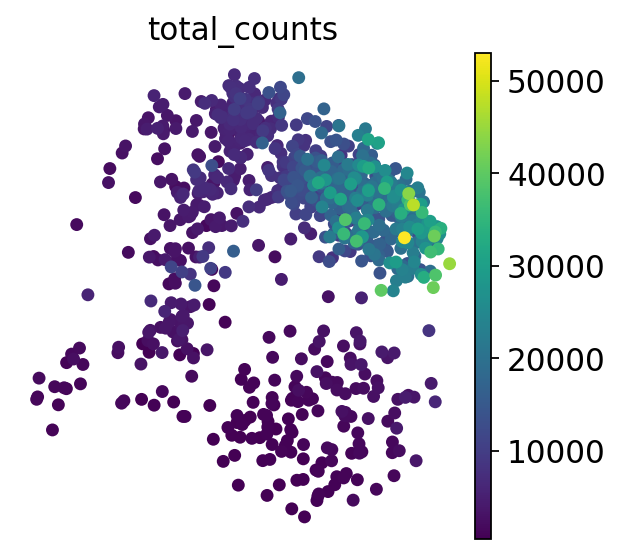

In [13]:
sc.pl.pca_scatter(adata, color="total_counts")

## t-SNE

In [14]:
sc.tl.tsne(adata, use_rep="X_pca")

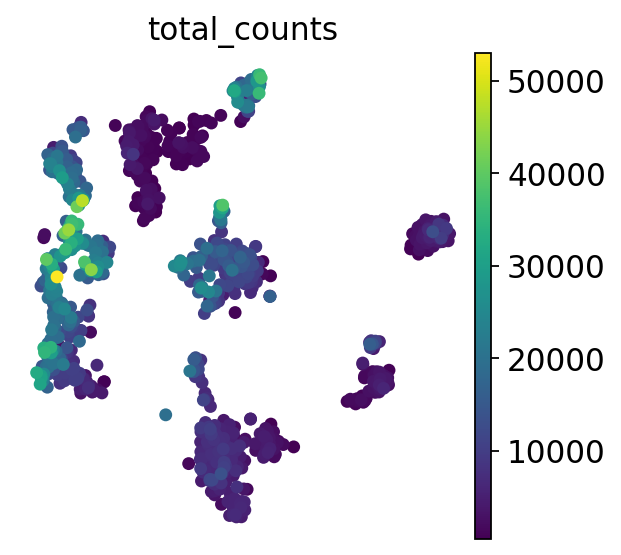

In [15]:
sc.pl.tsne(adata, color="total_counts")

## UMAP

In [16]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

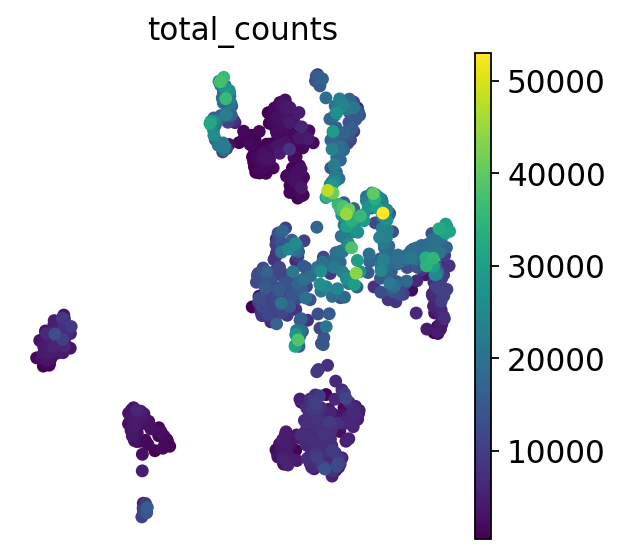

In [17]:
sc.pl.umap(adata, color="total_counts")

## Inspecting quality control metrics

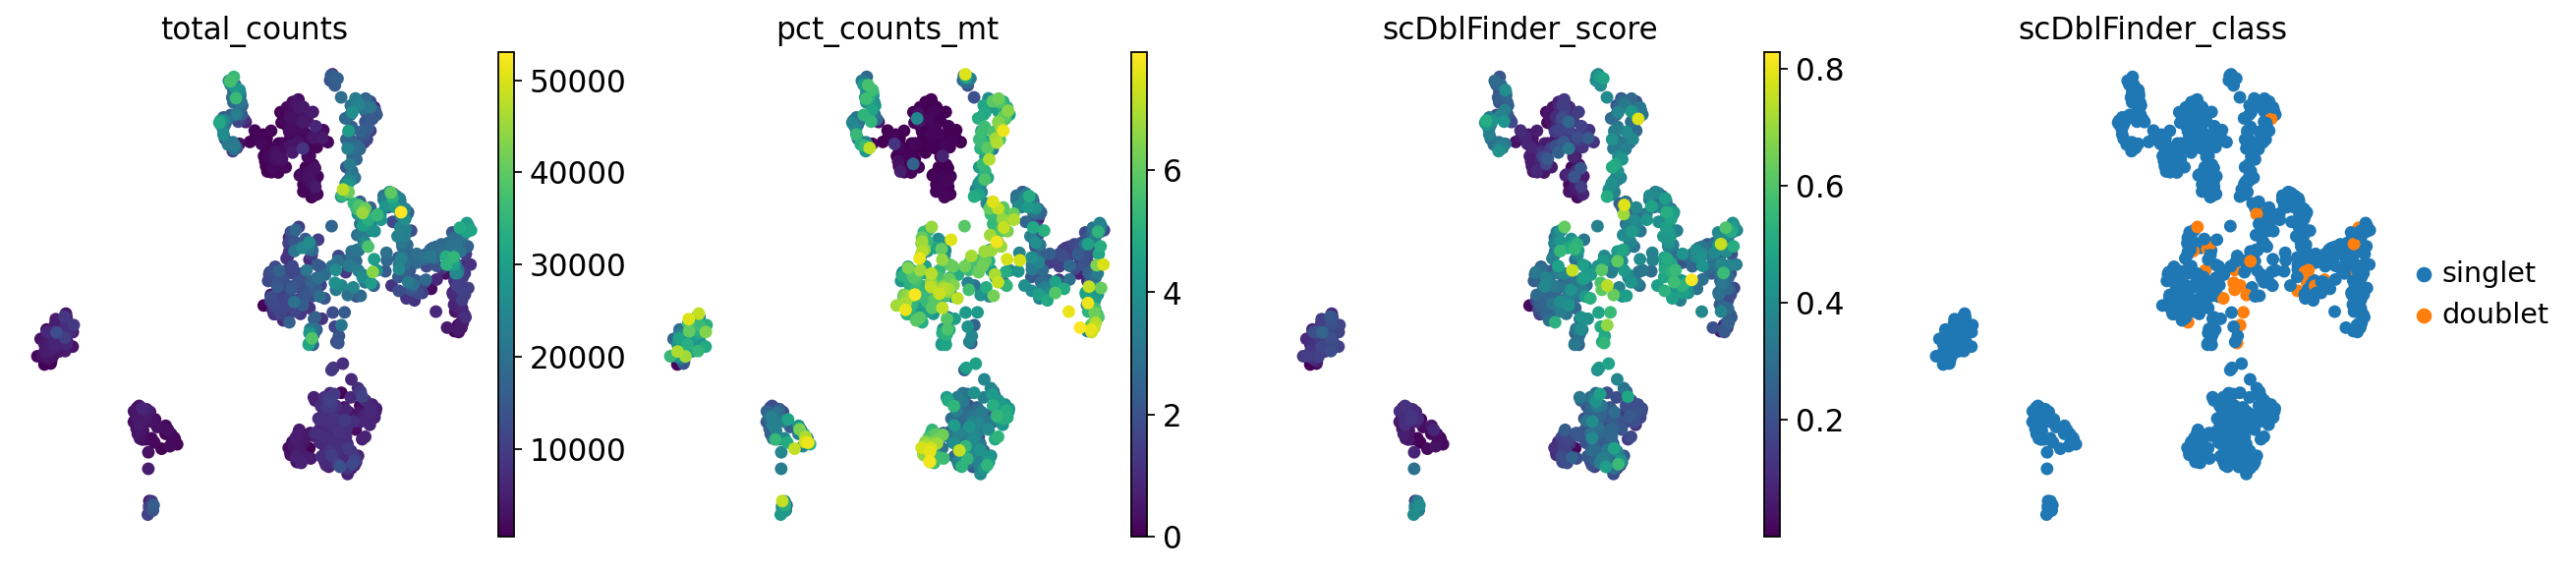

In [18]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class"],
)

In [20]:
# save the dataset to file
anndata.settings.allow_write_nullable_strings = True
adata.write("dimensionality_reduction.h5ad.gz", compression='gzip')